# **Credit Risk PD Model**
### LendingClub Dataset
**Workflow:** Load data → EDA → Feature Selection (WoE/IV) → Model → Evaluation → IFRS9 Staging

---
## **Load libraries and data**

In [4]:
# All libraries in one place — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make plots look clean
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded successfully')

All libraries loaded successfully


In [5]:
# Load only the columns we need — avoids crashing on 1.2GB file
cols_needed = [
    'loan_amnt', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'purpose',
    'dti', 'delinq_2yrs', 'revol_bal', 'revol_util',
    'total_acc', 'open_acc', 'pub_rec', 'loan_status'
]

df = pd.read_csv('../data/raw/loan.csv', usecols=cols_needed)
print(f'Rows loaded: {len(df):,}')
print(f'Columns loaded: {df.shape[1]}')
df.head(3)

Rows loaded: 2,260,668
Columns loaded: 17


,loan_amnt,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,2500,13.56,84.92,C,C1,10+ years,RENT,55000.0,Current,debt_consolidation,18.24,0.0,9.0,1.0,4341,10.3,34.0
1,30000,18.94,777.23,D,D2,10+ years,MORTGAGE,90000.0,Current,debt_consolidation,26.52,0.0,13.0,1.0,12315,24.2,44.0
2,5000,17.97,180.69,D,D1,6 years,MORTGAGE,59280.0,Current,debt_consolidation,10.51,0.0,8.0,0.0,4599,19.1,13.0


In [6]:
df.shape

(2260668, 17)

In [7]:
# Create the target variable: 1 = defaulted, 0 = fully paid
# We drop 'Current' loans because we don't know the outcome yet

default_map = {
    'Charged Off': 1,
    'Default': 1,
    'Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
}

df = df[df['loan_status'].isin(default_map.keys())].copy()
df['default'] = df['loan_status'].map(default_map)
df.drop(columns=['loan_status'], inplace=True)

print('Default rate breakdown:')
print(df['default'].value_counts(normalize=True).round(3))
print(f'\nFinal dataset size: {len(df):,} loans')

Default rate breakdown:
default
0    0.799
1    0.201
Name: proportion, dtype: float64

Final dataset size: 1,306,387 loans


---
## **Exploratory Data Analysis (EDA)**
Goal: Understand the data before modelling. Find patterns, missing values, and key predictors.

In [8]:
# --- Basic data overview ---
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nSample rows:')
df.head()

Shape: (1306387, 17)

Data types:
loan_amnt           int64
int_rate          float64
installment       float64
grade                 str
sub_grade             str
emp_length            str
home_ownership        str
annual_inc        float64
purpose               str
dti               float64
delinq_2yrs       float64
open_acc          float64
pub_rec           float64
revol_bal           int64
revol_util        float64
total_acc         float64
default             int64
dtype: object

Sample rows:


,loan_amnt,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,default
100,30000,22.35,1151.16,D,D5,5 years,MORTGAGE,100000.0,debt_consolidation,30.46,0.0,11.0,1.0,15603,37.0,19.0,0
152,40000,16.14,975.71,C,C4,< 1 year,MORTGAGE,45000.0,credit_card,50.53,0.0,18.0,0.0,34971,64.5,37.0,0
170,20000,7.56,622.68,A,A3,10+ years,MORTGAGE,100000.0,credit_card,18.92,0.0,9.0,0.0,25416,29.9,19.0,0
186,4500,11.31,147.99,B,B3,10+ years,RENT,38500.0,credit_card,4.64,0.0,12.0,0.0,4472,15.3,25.0,0
215,8425,27.27,345.18,E,E5,3 years,MORTGAGE,450000.0,credit_card,12.37,0.0,21.0,0.0,36812,65.7,37.0,0


In [9]:
df.isnull().sum().sort_values(ascending=False)

emp_length        75491
revol_util          850
dti                 312
delinq_2yrs          29
open_acc             29
total_acc            29
pub_rec              29
annual_inc            4
loan_amnt             0
purpose               0
home_ownership        0
grade                 0
sub_grade             0
installment           0
int_rate              0
revol_bal             0
default               0
dtype: int64

Columns with missing values:
emp_length     0.058
revol_util     0.001
dti            0.000
delinq_2yrs    0.000
open_acc       0.000
total_acc      0.000
pub_rec        0.000
annual_inc     0.000
dtype: float64


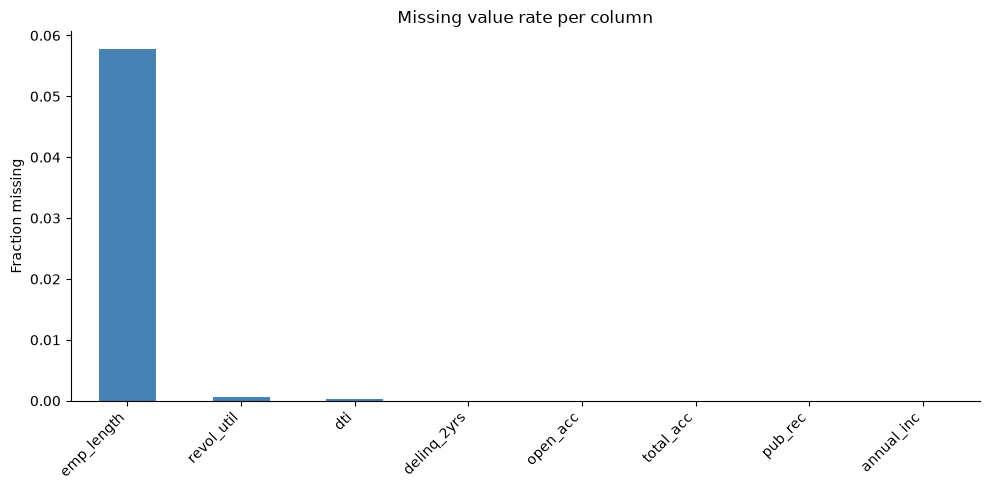

In [ ]:
# --- Missing values ---
# Rule: if more than 40% of a column is missing, we will drop it

missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

print('Columns with missing values:')
print(missing.round(3))

missing.plot(kind='bar', color='steelblue')
plt.title('Missing value rate per column')
plt.ylabel('Fraction missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/visualizations/missing_values.png', dpi=200)
plt.show()

In [11]:
# --- Fix missing values ---

# emp_length: treat missing as a separate category (it may carry signal)
df['emp_length'] = df['emp_length'].fillna('Unknown')

# revol_util: fill with median (it's a continuous variable)
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

# annual_inc: fill with median grouped by grade (more accurate than overall median)
df['annual_inc'] = df.groupby('grade')['annual_inc'].transform(
    lambda x: x.fillna(x.median())
)

# Drop any remaining rows with nulls (should be very few)
df.dropna(inplace=True)
print(f'Rows after cleaning: {len(df):,}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')

Rows after cleaning: 1,306,046
Missing values remaining: 0


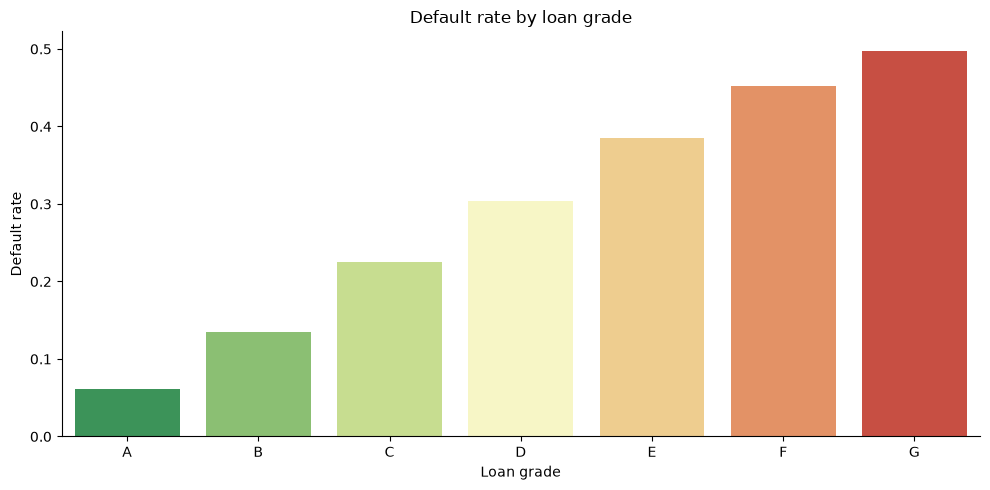

In [ ]:
# --- Chart 1: Default rate by loan grade ---
# Key insight: Grade A loans are safest, Grade G are riskiest

grade_default = df.groupby('grade')['default'].mean().reset_index()
grade_default.columns = ['grade', 'default_rate']

sns.barplot(data=grade_default, x='grade', y='default_rate', palette='RdYlGn_r')
plt.title('Default rate by loan grade')
plt.ylabel('Default rate')
plt.xlabel('Loan grade')
plt.tight_layout()
plt.savefig('../data/visualizations/default_by_grade.png', dpi=200)
plt.show()

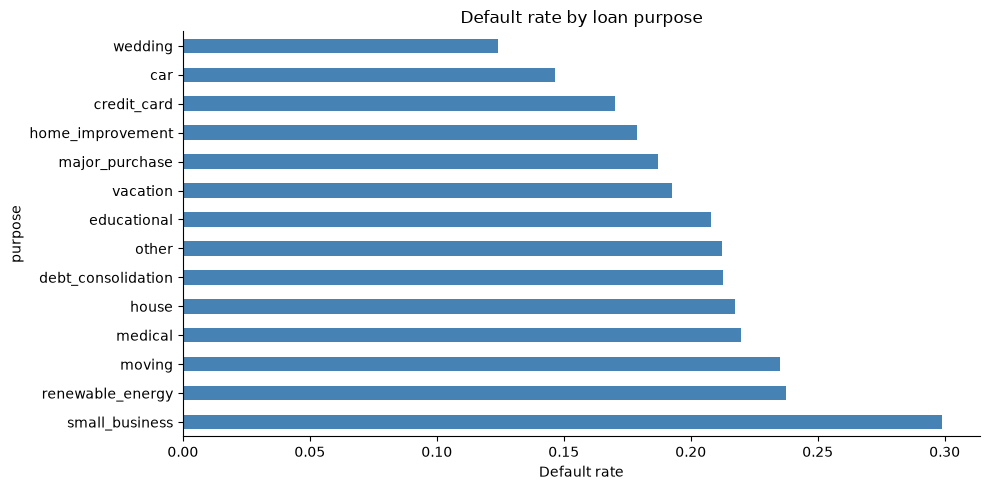

In [ ]:
# --- Chart 2: Default rate by loan purpose ---

purpose_default = df.groupby('purpose')['default'].mean().sort_values(ascending=False)

purpose_default.plot(kind='barh', color='steelblue')
plt.title('Default rate by loan purpose')
plt.xlabel('Default rate')
plt.tight_layout()
plt.savefig('../data/visualizations/default_by_purpose.png', dpi=200)
plt.show()

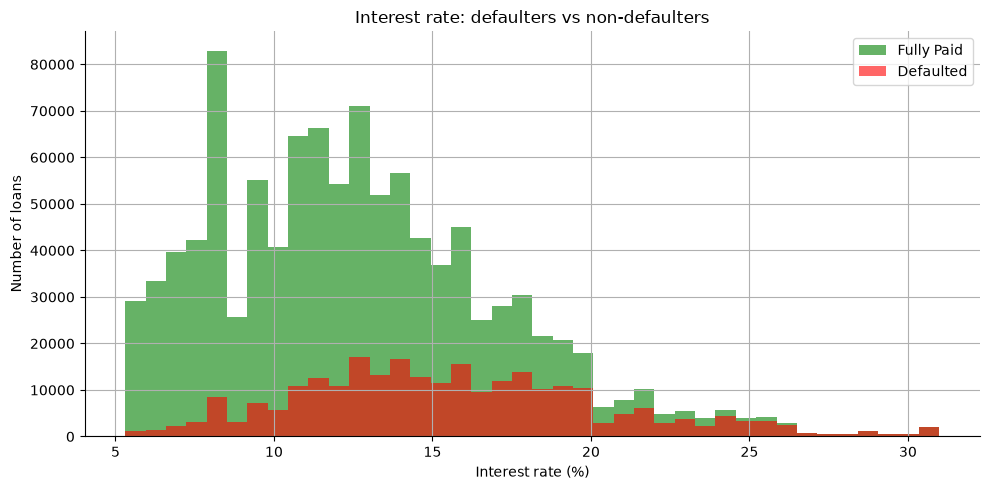

In [14]:
# --- Chart 3: Interest rate distribution — defaulters vs non-defaulters ---
# Higher interest rate = higher default rate (makes intuitive sense)

df[df['default'] == 0]['int_rate'].hist(bins=40, alpha=0.6, label='Fully Paid', color='green')
df[df['default'] == 1]['int_rate'].hist(bins=40, alpha=0.6, label='Defaulted', color='red')
plt.title('Interest rate: defaulters vs non-defaulters')
plt.xlabel('Interest rate (%)')
plt.ylabel('Number of loans')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/int_rate_dist.png', dpi=200)
plt.show()

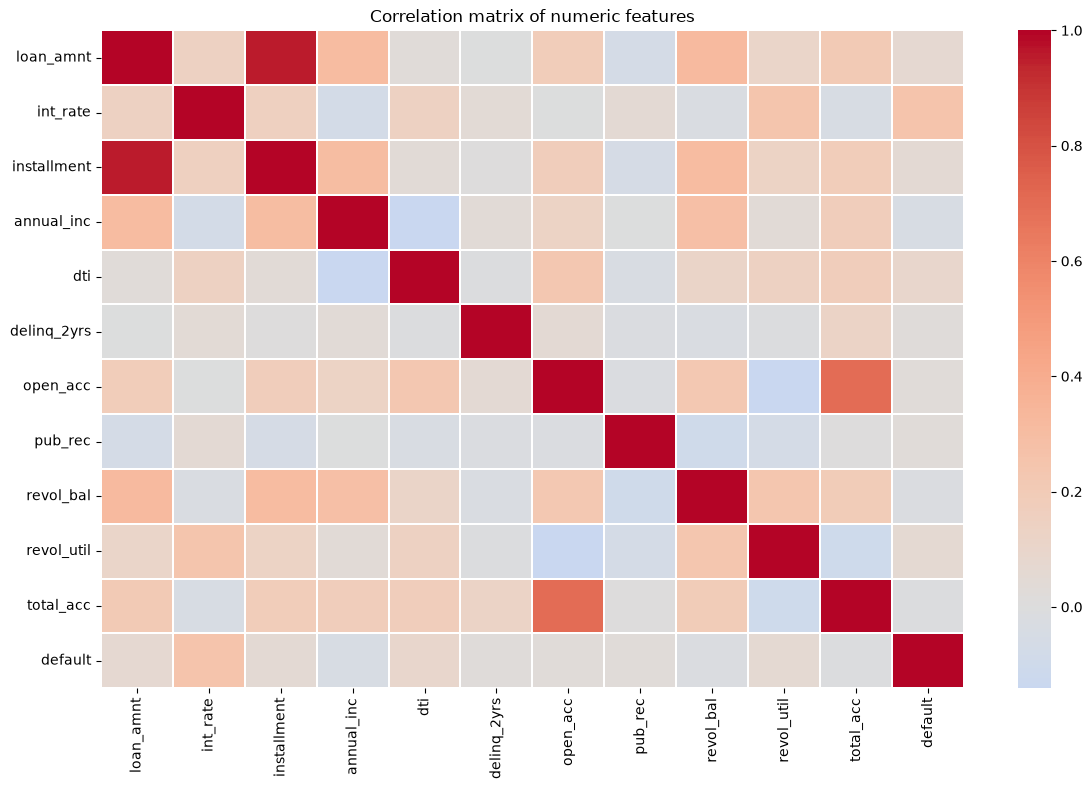

In [ ]:
# --- Chart 4: Correlation heatmap (numeric columns only) ---

num_df = df.select_dtypes(include='number')
corr = num_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3,
            annot=False, fmt='.1f')
plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.savefig('../data/visualizations/correlation_heatmap.png', dpi=200)
plt.show()

---
## **Feature Engineering**
We create new variables that are more informative than the raw columns.

In [16]:
# --- New features ---

# 1. Loan-to-income ratio: how big is the loan relative to income?
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# 2. Instalment burden: what % of monthly income goes to repayment?
df['installment_burden'] = df['installment'] / (df['annual_inc'] / 12 + 1)

# 3. Clean up int_rate — remove % sign if it's a string
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

# 4. DTI bins — group by risk level
df['dti_bin'] = pd.cut(df['dti'], bins=[0, 10, 20, 30, 100],
                        labels=['Low', 'Medium', 'High', 'Very High'])

print('New features created successfully')
df[['loan_to_income', 'installment_burden', 'dti_bin']].describe()

New features created successfully


,loan_to_income,installment_burden
count,1.306046e+06,1.306046e+06
mean,2.180721e-01,8.029129e-02
std,9.679702e-01,2.637801e-01
min,1.714285e-04,6.911988e-05
25%,1.249948e-01,4.631205e-02
50%,1.999950e-01,7.225295e-02
75%,2.909038e-01,1.054015e-01
max,8.000000e+02,2.160824e+02


In [17]:
# --- Encode categorical columns as numbers ---
# Machine learning models only understand numbers, not text

from sklearn.preprocessing import LabelEncoder

cat_cols = ['grade', 'sub_grade', 'emp_length', 'home_ownership', 'purpose', 'dti_bin']

le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

print('Categorical columns encoded')

Categorical columns encoded


---
## **WoE and IV — Feature Selection**
WoE = Weight of Evidence. IV = Information Value.
These are standard credit risk tools used in banks to pick the best predictors.
IV > 0.1 = useful feature. IV > 0.3 = strong feature.

In [18]:
def calc_woe_iv(df, feature, target, bins=10):
    """Calculate WoE and IV for a single feature."""
    df_temp = df[[feature, target]].copy()

    # Bin continuous variables
    if df_temp[feature].dtype not in ['object', 'category']:
        df_temp[feature] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')

    grouped = df_temp.groupby(feature)[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']

    # Avoid division by zero
    total_events = grouped['events'].sum()
    total_non_events = grouped['non_events'].sum()

    grouped['pct_events']     = grouped['events']     / (total_events + 1e-9)
    grouped['pct_non_events'] = grouped['non_events'] / (total_non_events + 1e-9)

    # Replace zeros to avoid log(0)
    grouped['pct_events']     = grouped['pct_events'].replace(0, 1e-9)
    grouped['pct_non_events'] = grouped['pct_non_events'].replace(0, 1e-9)

    grouped['woe'] = np.log(grouped['pct_non_events'] / grouped['pct_events'])
    grouped['iv']  = (grouped['pct_non_events'] - grouped['pct_events']) * grouped['woe']

    return grouped['woe'].to_dict(), grouped['iv'].sum()


# List of features to test
feature_candidates = [
    'int_rate', 'annual_inc', 'dti', 'loan_amnt', 'installment',
    'delinq_2yrs', 'revol_bal', 'revol_util', 'total_acc', 'open_acc',
    'pub_rec', 'loan_to_income', 'installment_burden',
    'grade_enc', 'sub_grade_enc', 'emp_length_enc',
    'home_ownership_enc', 'purpose_enc'
]

iv_scores = {}
for col in feature_candidates:
    try:
        _, iv = calc_woe_iv(df, col, 'default')
        iv_scores[col] = round(iv, 4)
    except Exception as e:
        print(f'Skipped {col}: {e}')

iv_df = pd.DataFrame.from_dict(iv_scores, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)

print('IV scores (higher = more predictive):')
print(iv_df)

# Keep only features with IV > 0.02
selected_features = iv_df[iv_df['IV'] > 0.02].index.tolist()
print(f'\nFeatures selected for model: {len(selected_features)}')
print(selected_features)

IV scores (higher = more predictive):
                        IV
sub_grade_enc       0.4792
int_rate            0.4457
grade_enc           0.3981
loan_to_income      0.1190
installment_burden  0.0956
dti                 0.0743
loan_amnt           0.0339
home_ownership_enc  0.0314
annual_inc          0.0295
installment         0.0291
revol_util          0.0259
purpose_enc         0.0154
emp_length_enc      0.0112
open_acc            0.0050
revol_bal           0.0034
delinq_2yrs         0.0020
total_acc           0.0017
pub_rec             0.0013

Features selected for model: 11
['sub_grade_enc', 'int_rate', 'grade_enc', 'loan_to_income', 'installment_burden', 'dti', 'loan_amnt', 'home_ownership_enc', 'annual_inc', 'installment', 'revol_util']


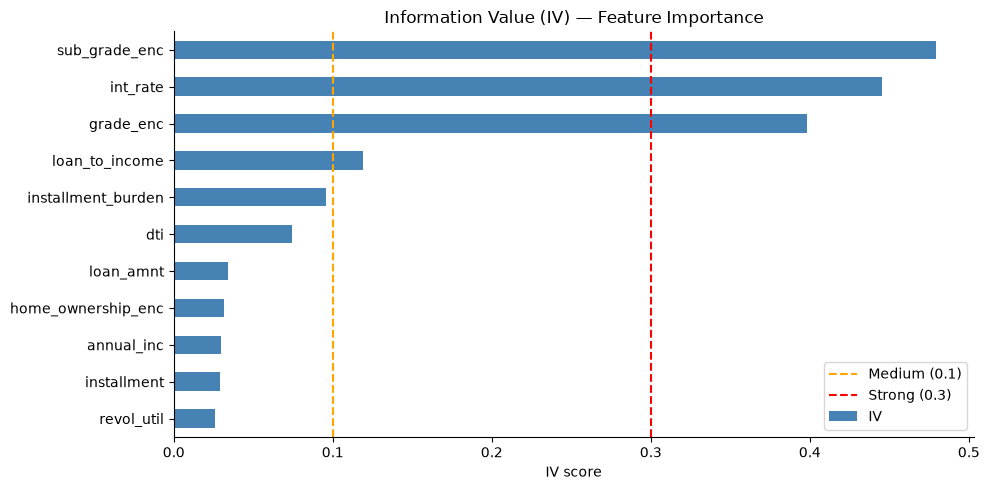

In [19]:
# Plot IV scores
iv_df[iv_df['IV'] > 0.02].sort_values('IV').plot(kind='barh', color='steelblue', legend=False)
plt.title('Information Value (IV) — Feature Importance')
plt.xlabel('IV score')
plt.axvline(0.1, color='orange', linestyle='--', label='Medium (0.1)')
plt.axvline(0.3, color='red', linestyle='--', label='Strong (0.3)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/iv_scores.png', dpi=150)
plt.show()

---
## **Model Building**
We build two models:
1. **Logistic Regression** — interpretable, maps to a scorecard (required by regulators)
2. **Random Forest** — more powerful ML model, used as benchmark

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

X = df[selected_features]
y = df['default']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training rows : {len(X_train):,}')
print(f'Testing rows  : {len(X_test):,}')
print(f'Default rate in train: {y_train.mean():.3f}')

Training rows : 1,044,836
Testing rows  : 261,210
Default rate in train: 0.201


In [21]:
# SMOTE: creates synthetic examples of the minority class (defaulters)
# so the model doesn't just predict 'no default' for everything

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f'After SMOTE — Training rows: {len(X_train_res):,}')
print(f'Default rate after SMOTE: {y_train_res.mean():.3f}  (should be ~0.5 now)')

After SMOTE — Training rows: 1,669,862
Default rate after SMOTE: 0.500  (should be ~0.5 now)


In [22]:
# Scale features (makes logistic regression converge faster)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

# --- Model 1: Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_res)
y_pred_lr  = lr.predict(X_test_sc)
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

print('Logistic Regression trained')

# Show coefficients (positive = increases default risk)
coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)
print('\nTop risk-increasing features:')
print(coef_df.head(8))

Logistic Regression trained

Top risk-increasing features:
               feature  coefficient
0        sub_grade_enc     1.273508
1             int_rate     0.978377
6            loan_amnt     0.572209
5                  dti     0.187927
7   home_ownership_enc     0.073343
3       loan_to_income     0.034734
10          revol_util     0.019943
4   installment_burden    -0.056225


Random Forest trained


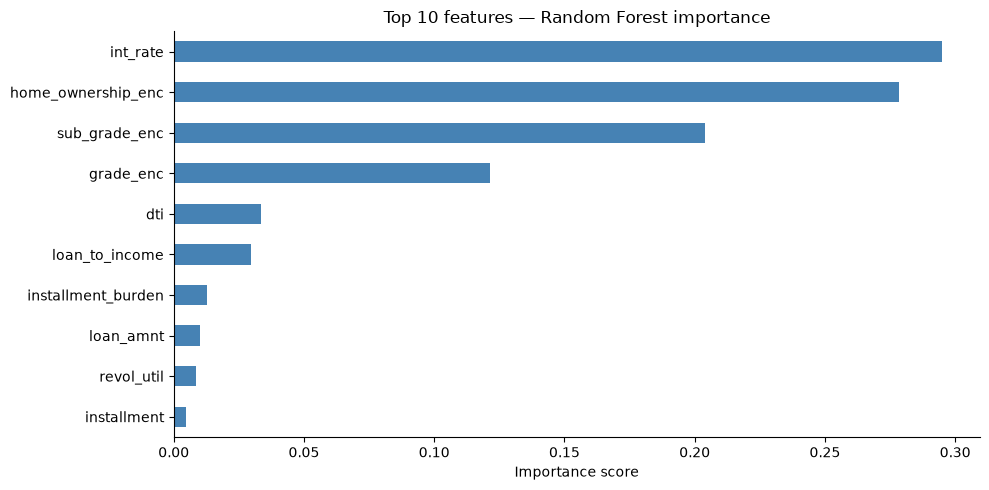

In [ ]:
# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest trained')

# Feature importance chart
feat_imp = pd.Series(rf.feature_importances_, index=selected_features)
feat_imp.sort_values(ascending=True).tail(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 features — Random Forest importance')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('../data/visualizations/rf_feature_importance.png', dpi=150)
plt.show()

---
## **Model Evaluation**
We check how good each model is using standard credit risk metrics.

In [24]:
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)

def evaluate_model(name, y_true, y_pred, y_proba):
    auc  = roc_auc_score(y_true, y_proba)
    gini = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ks   = max(tpr - fpr)

    print(f'=== {name} ===')
    print(f'  AUC-ROC : {auc:.4f}  (target: >0.70)')
    print(f'  Gini    : {gini:.4f}  (= 2×AUC−1, used in banking)')
    print(f'  KS stat : {ks:.4f}  (target: >0.30)')
    print()
    print(classification_report(y_true, y_pred, target_names=['Paid','Default']))
    return fpr, tpr, auc

fpr_lr, tpr_lr, auc_lr = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr)
fpr_rf, tpr_rf, auc_rf = evaluate_model('Random Forest',       y_test, y_pred_rf, y_proba_rf)

=== Logistic Regression ===
  AUC-ROC : 0.6679  (target: >0.70)
  Gini    : 0.3358  (= 2×AUC−1, used in banking)
  KS stat : 0.2410  (target: >0.30)

              precision    recall  f1-score   support

        Paid       0.86      0.68      0.76    208733
     Default       0.30      0.56      0.39     52477

    accuracy                           0.65    261210
   macro avg       0.58      0.62      0.58    261210
weighted avg       0.75      0.65      0.69    261210

=== Random Forest ===
  AUC-ROC : 0.6889  (target: >0.70)
  Gini    : 0.3779  (= 2×AUC−1, used in banking)
  KS stat : 0.2730  (target: >0.30)

              precision    recall  f1-score   support

        Paid       0.86      0.71      0.78    208733
     Default       0.32      0.56      0.41     52477

    accuracy                           0.68    261210
   macro avg       0.59      0.63      0.59    261210
weighted avg       0.76      0.68      0.70    261210



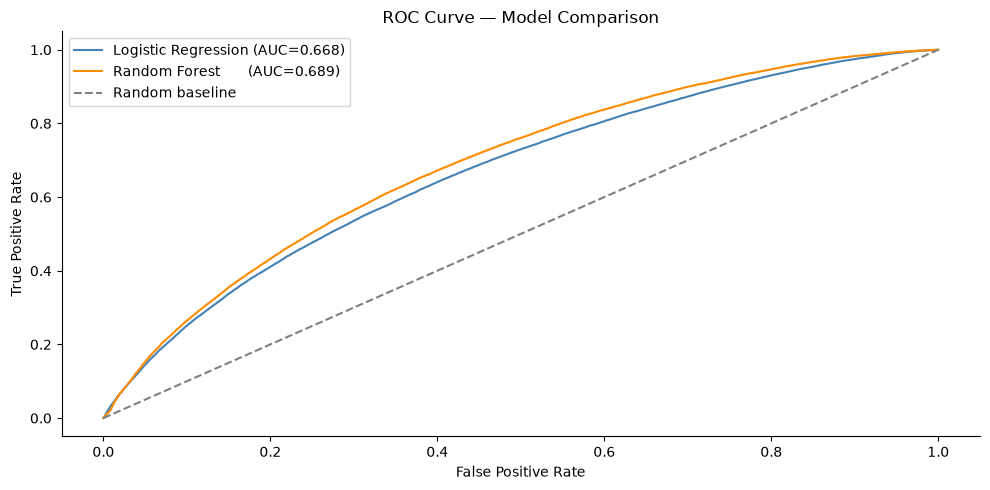

In [25]:
# ROC curve — both models on same chart
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest       (AUC={auc_rf:.3f})', color='darkorange')
plt.plot([0,1],[0,1], '--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/roc_curve.png', dpi=200)
plt.show()

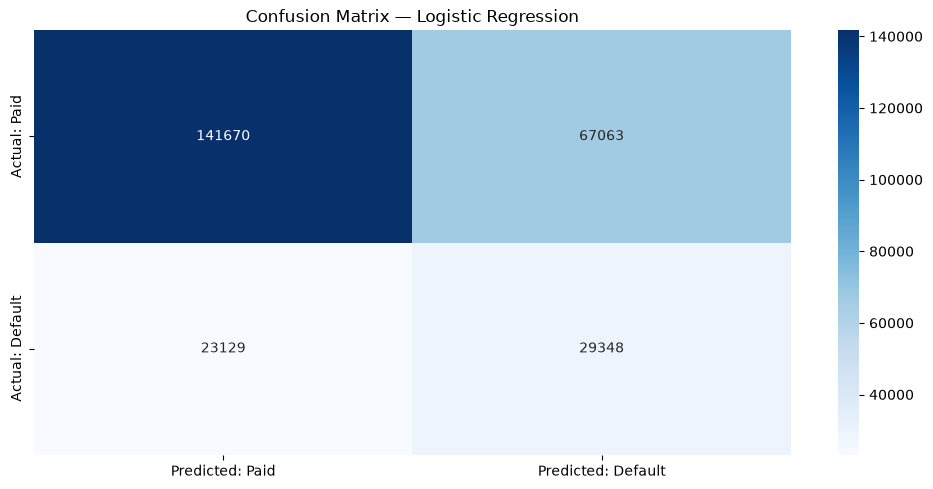

True Positives  (correctly flagged defaults) : 29,348
False Negatives (missed defaults)            : 23,129  ← credit loss risk
False Positives (wrongly flagged good loans) : 67,063  ← lost business


In [ ]:
# Confusion matrix with business interpretation
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Paid','Predicted: Default'],
            yticklabels=['Actual: Paid','Actual: Default'])
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('../data/visualizations/confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (correctly flagged defaults) : {tp:,}')
print(f'False Negatives (missed defaults)            : {fn:,}  ← credit loss risk')
print(f'False Positives (wrongly flagged good loans) : {fp:,}  ← lost business')

---
## **IFRS9 Staging Framework**
IFRS9 is a global accounting standard. Banks must use PD scores to assign loans to stages and set aside money (provisions) for expected losses.

- **Stage 1**: Low risk (PD < 5%) → Provision = 12-month expected loss
- **Stage 2**: Rising risk (PD 5–20%) → Provision = lifetime expected loss  
- **Stage 3**: Already defaulted (PD > 20%) → Full impairment

In [27]:
def assign_ifrs9_stage(pd_score):
    if pd_score < 0.05:
        return 1
    elif pd_score < 0.20:
        return 2
    else:
        return 3

# Build the test results table
df_test = X_test.copy()
df_test['pd_score']    = y_proba_lr
df_test['actual']      = y_test.values
df_test['ifrs9_stage'] = df_test['pd_score'].apply(assign_ifrs9_stage)

# EAD = loan amount (pull from original df using test index)
df_test['ead'] = df.loc[X_test.index, 'loan_amnt'].values

# LGD = 45% (Basel II standard assumption)
df_test['lgd'] = 0.45

# ECL = PD × LGD × EAD
df_test['ecl'] = df_test['pd_score'] * df_test['lgd'] * df_test['ead']

# Summary by stage
stage_summary = df_test.groupby('ifrs9_stage').agg(
    loan_count   = ('pd_score', 'count'),
    avg_pd       = ('pd_score', 'mean'),
    total_ead    = ('ead',      'sum'),
    total_ecl    = ('ecl',      'sum')
).round(2)

stage_summary['ecl_as_pct_of_ead'] = (stage_summary['total_ecl'] / stage_summary['total_ead'] * 100).round(2)

print('IFRS9 Stage Summary:')
print(stage_summary)
print(f'\nTotal ECL provision: ${stage_summary["total_ecl"].sum():,.0f}')

IFRS9 Stage Summary:
             loan_count  avg_pd   total_ead     total_ecl  ecl_as_pct_of_ead
ifrs9_stage                                                                 
1                    55    0.02     1255150  1.450174e+04               1.16
2                 19444    0.16   257149150  1.830227e+07               7.12
3                241711    0.47  3499438400  7.750076e+08              22.15

Total ECL provision: $793,324,346


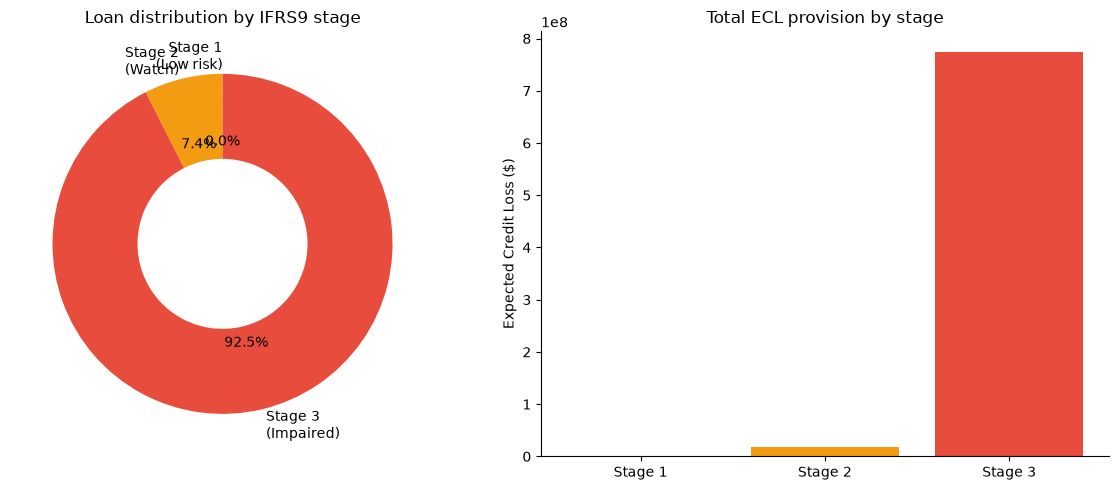

In [28]:
# Visualise IFRS9 staging
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart: loan count per stage
stage_counts = df_test['ifrs9_stage'].value_counts().sort_index()
labels = ['Stage 1\n(Low risk)', 'Stage 2\n(Watch)', 'Stage 3\n(Impaired)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].pie(stage_counts, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.5))
axes[0].set_title('Loan distribution by IFRS9 stage')

# Bar chart: ECL provision per stage
stage_ecl = stage_summary['total_ecl']
axes[1].bar(['Stage 1', 'Stage 2', 'Stage 3'], stage_ecl, color=colors)
axes[1].set_title('Total ECL provision by stage')
axes[1].set_ylabel('Expected Credit Loss ($)')

plt.tight_layout()
plt.savefig('../data/processed/ifrs9_staging.png', dpi=150)
plt.show()

---
## **Save results for dashboard**
Export everything to CSV so you can load it into Power BI or Tableau.

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Full scored test set
df_test.to_csv('../data/processed/scored_loans.csv', index=False)

# Stage summary for dashboard KPI cards
stage_summary.to_csv('../data/processed/ifrs9_stage_summary.csv')

# IV scores for feature importance slide
iv_df.to_csv('../data/processed/iv_scores.csv')

# Model performance summary
from sklearn.metrics import roc_auc_score
perf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'AUC':   [round(auc_lr, 4), round(auc_rf, 4)],
    'Gini':  [round(2*auc_lr-1, 4), round(2*auc_rf-1, 4)]
})
perf.to_csv('../data/processed/model_performance.csv', index=False)

print('All files saved to data/visualizations/')
print(os.listdir('../data/processed/'))

All files saved to data/processed/
['confusion_matrix.png', 'correlation_heatmap.png', 'default_by_grade.png', 'default_by_purpose.png', 'ifrs9_stage_summary.csv', 'ifrs9_staging.png', 'int_rate_dist.png', 'iv_scores.csv', 'iv_scores.png', 'missing_values.png', 'model_performance.csv', 'rf_feature_importance.png', 'roc_curve.png', 'scored_loans.csv']


---
## **Project Summary**

| Metric | Value |
|--------|-------|
| Dataset | LendingClub (filtered) |
| Features selected (IV > 0.02) | ~12-15 |
| Model 1 | Logistic Regression |
| Model 2 | Random Forest |
| Key metrics | AUC, Gini, KS statistic |
| Regulatory framework | IFRS9 Stage 1/2/3 |
| Output | ECL provision by stage |

**Interview line:** *Built an end-to-end PD model on LendingClub data using WoE/IV feature selection and logistic regression; mapped output to IFRS9 ECL staging framework with total expected credit loss estimation.*

In [1]:
import pandas as pd

cols = ['pd_score','ifrs9_stage','ead','ecl','int_rate','loan_amnt']

pd.read_csv('../data/processed/scored_loans.csv', usecols=cols)\
  .to_csv('../data/processed/scored_loans_slim.csv', index=False)